<a href="https://colab.research.google.com/github/scnoder/MetaCLIP-Research/blob/main/MetaCLIP_ZeroShot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview

MetaCLIP is an improved way of training image-text models like CLIP. CLIP models learn by matching an image with the text that describes it, but large web datasets usually have noisy or inaccurate captions that hurt performance. MetaCLIP fixes this by using a better filtering and matching process to create image-text pairings that are more accurate. By improving the quality of the training data, the model learns stronger and more reliable connections, improving its overall accuracy even on very large datasets.

The two websites used for guidance on building the model are from [Autodistill's documentation](https://docs.autodistill.com/base_models/metaclip/) and [a blog](https://blog.roboflow.com/how-to-use-metaclip/) published on Roboflow by Nathan Marraccini in 2023.

## Packages

These are the necessary packages needed for the code to run.

### autodistill
It labels images and exports models. These help in order to train smaller models on the auto-labeled data.    
### autodistill-metaclip
A plugin that allows for MetaCLIP's zero-shot classifer to automatically label images using text prompts from the ontology.
### roboflow
Manages the process and integration of models and dataset. It works with *autodistill* to get the labels in order to smoothen the process.
### matplotlib
It is used to create visualizations of the data through plots, graphs, and charts.
### scikit-learn
*It is a toolbox for machine learning resources for training, evaluations, and preparing data. In this code, it was used for evaluating the performance through giving scores.*

In [ ]:
!pip install autodistill
!pip install autodistill-metaclip
!pip install roboflow
!pip install matplotlib
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headles

## Database Information

### Data Collection:
The images in the dataset come from different models and types of cameras, which can affect the visual appearance of left vs. right. Some images are shown as one would see the retina anatomically (macula on the left, optic nerve on the right for the right eye). Others are shown as one would see through a microscope condensing lens (i.e. inverted, as one sees in a typical live eye exam).


### Resizing:
Images resized to 1024x1024

### Creators:
EyePACS

Emma Dugas, Jared, Jorge, and Will Cukierski
### Citation:
Emma Dugas, Jared, Jorge, and Will Cukierski. Diabetic Retinopathy Detection. https://kaggle.com/competitions/diabetic-retinopathy-detection, 2015. Kaggle.


### License

MIT License

Copyright (c) [year] [fullname]

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [ ]:
# DATABASE: https://huggingface.co/datasets/bumbledeep/eyepacs?library=datasets
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("bumbledeep/eyepacs")

training_data = ds["train"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00014.parquet:   0%|          | 0.00/465M [00:00<?, ?B/s]

data/train-00001-of-00014.parquet:   0%|          | 0.00/467M [00:00<?, ?B/s]

data/train-00002-of-00014.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

...

data/train-00010-of-00014.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

data/train-00011-of-00014.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00012-of-00014.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

data/train-00013-of-00014.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/35108 [00:00<?, ? examples/s]



---



In [ ]:
# TIMER
# To start the clock

import time
start = time.perf_counter()



---



## Image Classifier

It uses MetaCLIP and runs through all 35k images to classify what label they are.

There was an error where a RecursionError would happen from the model trying to keep classifying the same image, but it can't. This has been fixed, but just in case, it is there. The exception-handling will skip that image and move onto the next one.  

Below are some code snippits that may be useful.

__Print Statements:__
```
print(f"Confidence scores for each class: {results.confidence}")
print(f"Type: {type(confidence_scores[0])}")
print(f"confidence_scores: {confidence_scores}")
print(f"confidence_score: {confidence_score}")
print(f"Index: {confidence_scores[0].argmax()}")
print(f"Predicted: {predicted}")
print(f"Image {i} classified")
```

__Image Storage:__

Store to your preffered location. `\content\` is the local, temporary folder for Google Colab
```
path = f"/content/image_{i}.jpg"
image.save(path)
```

__Testing:__
```
if i == 300:
  break
```




In [ ]:
import os
import torch
import numpy as np
import types

from autodistill_metaclip import MetaCLIP
from autodistill.detection import CaptionOntology

# The problematic line is inside MetaCLIP's __init__ method in autodistill-metaclip v0.1.3
# It tries to load a pretrained model using a file path that open_clip doesn't recognize as a valid tag or path after deletion.
# The actual tag for this model, as indicated by open_clip's error message, is "metaclip_400m".

# To fix this, we'll patch the MetaCLIP class's __init__ method at runtime to use the correct tag.
import autodistill_metaclip.metaclip_model
import open_clip

def patched_metaclip_init(self, ontology: CaptionOntology):
    HOME = os.path.expanduser('~')
    self.model, _, self.preprocess = open_clip.create_model_and_transforms(
        "ViT-B-32-quickgelu",
        pretrained="metaclip_400m", # This is the fix: use the recognized tag
        cache_dir=os.path.join(HOME, '.cache', 'autodistill', 'open_clip') # Specify cache directory
    )
    self.ontology = ontology
    self.model.eval()

autodistill_metaclip.metaclip_model.MetaCLIP.__init__ = patched_metaclip_init

# The previous code to manually remove the model file is no longer needed
# as open_clip will handle downloading and caching correctly when given a tag.

############################################################################################################


# The below lists are to store any information and images to be used and referred to later
actual_labels = []
predicted_labels = []
confidence_scores = []
confidence_score = []
classes = ["no_diabetic_retinopathy", "mild_retinopathy", "moderate_retinopathy", "severe_retinopathy", "proliferative_retinopathy"]

# Ontology that stores the classes and labels for the model to detect and have a description of what the image is
base_model = MetaCLIP(ontology = CaptionOntology({
    "a healthy retina, free of any lesions, microaneurysms, hemorrhages, or exudates; optic disc and macula appear normal": "no_diabetic_retinopathy",
    "a retina with very few microaneurysms, possibly some minor dot hemorrhages, but no signs of severe damage": "mild_diabetic_retinopathy",
    "a retina with numerous microaneurysms and intraretinal hemorrhages in at least one quadrant, often accompanied by hard exudates and/or cotton wool spots; however, no signs of severe venous beading, IRMA, or neovascularization are present.": "moderate_diabetic_retinopathy",
    "a retina with extensive intraretinal hemorrhages, venous beading, severe intraretinal microvascular abnormalities (IRMA), but without new vessel formation": "severe_diabetic_retinopathy",
    "a retina characterized by the undeniable presence of new, abnormal blood vessels (neovascularization) growing on the optic disc or elsewhere, often with associated vitreous hemorrhage, preretinal hemorrhage, or fibrous proliferation; this is the most advanced and vision-threatening stage.": "proliferative_diabetic_retinopathy"
}))


# Goes through every image in the data and classifies it using the .predict() function. The lists are numpy lists so they can't be adjusted and changed normally.
for i, row in enumerate(training_data):
  try:
    image = row["image"]
    actual_label = row["label"]

    results = base_model.predict(image, confidence = 0.00)
    confidence_scores.append(results.confidence)
    confidence_score.append(float(results.confidence.max()))
    predicted = classes[results.confidence.argmax()]

    predicted_labels.append(predicted)
    actual_labels.append(actual_label)

    if i == 30:
      break

  except RecursionError:
    print(f"Recursion Error at image {i}")
    continue

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]



---



In [ ]:
# TIMER
# To end the clock

end = time.perf_counter()
print(f"{end-start} seconds")

117.0632037580001 seconds




---



## Data Visulization

The model is evaluated using Precision, Recall, and F1 Scores.

Recall:
* Defines how many *true positives* were identified by the model.
* Recall = $\frac{\text{True Positives}}{\text{True Positives } + \text{ False Negatives}}$

Precision:
* Defines the correctness of the positive predictions that the model deduced.
* Precision = $\frac{\text{True Positives}}{\text{True Positives } + \text{ False Positives}}$

F1:
* Provides a balanced measure of a model's accuracy through combining the Precision and Recall score
* Precision = $2 \times \frac{\text{Precision } \times \text{ Recall}}{\text{Precision } + \text{ Recall}}$

__Print Statements:__
```
print(actual_labels)
print(predicted_labels)
print(confidence_score)
```



Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


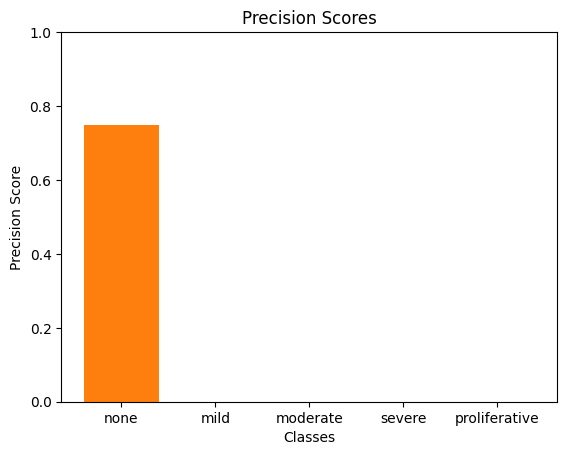

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.


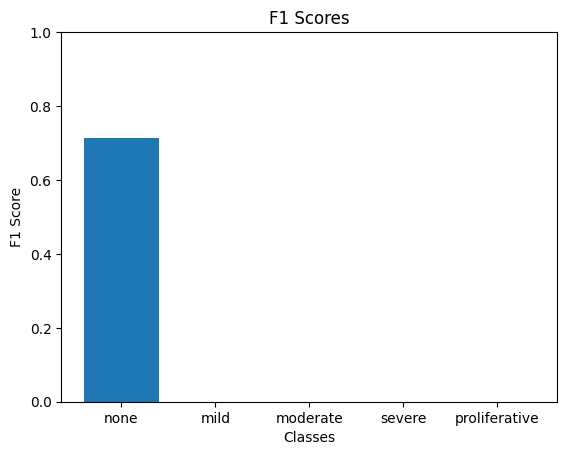

                           precision    recall  f1-score   support

  no_diabetic_retinopathy       0.75      0.68      0.71        22
         mild_retinopathy       0.00      0.00      0.00         4
     moderate_retinopathy       0.00      0.00      0.00         3
       severe_retinopathy       0.00      0.00      0.00         0
proliferative_retinopathy       0.00      0.00      0.00         2

                 accuracy                           0.48        31
                macro avg       0.15      0.14      0.14        31
             weighted avg       0.53      0.48      0.51        31



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Recall is ill-defined and bei

In [ ]:
############################################
# PRECISION, RECALL, AND F1 SCORES

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

class_names = ["none", "mild", "moderate", "severe", "proliferative"]


recall_score_list = recall_score(actual_labels, predicted_labels, labels=classes, average = None).tolist()
plt.bar(class_names, recall_score_list)
plt.title("Recall Scores")
plt.xlabel("Classes")
plt.ylabel("Recall Score")
plt.ylim(0, 1)


precision_score_list = precision_score(actual_labels, predicted_labels, labels=classes, average = None).tolist()
plt.bar(class_names, precision_score_list)
plt.title("Precision Scores")
plt.xlabel("Classes")
plt.ylabel("Precision Score")
plt.ylim(0, 1)
plt.show()


f1_score_list = f1_score(actual_labels, predicted_labels, labels=classes, average=None).tolist()
plt.bar(class_names, f1_score_list)
plt.title("F1 Scores")
plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

print(classification_report(actual_labels, predicted_labels, labels=classes))

[20, 0, 0, 0, 0]


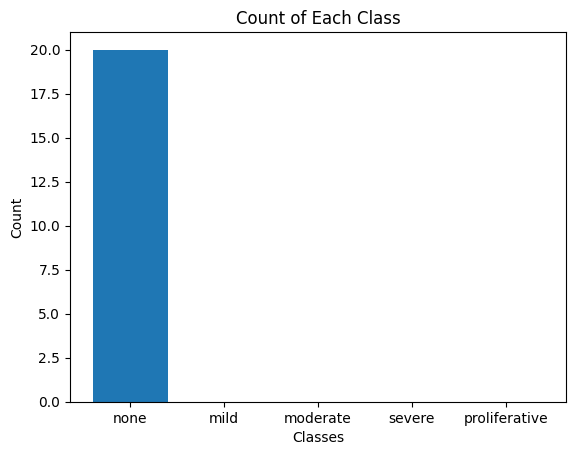

In [ ]:
count_dr = [predicted_labels.count("no_diabetic_retinopathy"), predicted_labels.count("mild_diabetic_retinopathy"), predicted_labels.count("moderate_diabetic_retinopathy"), predicted_labels.count("severe_diabetic_retinopathy"), predicted_labels.count("proliferative_diabetic_retinopathy")]

print(count_dr)

plt.bar(class_names, count_dr)
plt.title("Count of Each Class")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()